In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings(action="ignore")

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

In [3]:
df = pd.read_csv("academic_performance_dataset_V2.csv")

In [4]:
df.head()

,ID No,Prog Code,Gender,YoG,CGPA,CGPA100,CGPA200,CGPA300,CGPA400,SGPA
0,42308,ICE,Female,2010,3.23,2.88,3.48,2.62,2.90,3.13
1,70978,BCH,Female,2010,3.58,3.25,4.26,3.37,3.47,3.02
2,31602,BCH,Male,2010,2.21,1.78,1.98,1.49,2.51,2.19
3,63847,BCH,Male,2010,2.70,2.67,2.44,2.00,2.35,3.19
4,30158,BCH,Female,2010,3.88,3.61,3.69,3.63,4.58,4.24


In [5]:
df.tail()

,ID No,Prog Code,Gender,YoG,CGPA,CGPA100,CGPA200,CGPA300,CGPA400,SGPA
3041,64106,PHYG,Female,2013,4.18,4.04,4.23,4.16,4.28,3.20
3042,96596,PHYG,Male,2013,2.91,2.36,3.35,2.87,3.02,2.03
3043,64982,PHYG,Male,2013,3.66,3.42,3.83,3.55,3.82,3.33
3044,27052,PHYG,Female,2014,4.56,4.39,4.70,4.58,4.63,3.52
3045,65054,PHYG,Male,2014,4.18,4.29,4.43,3.68,4.14,4.10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3046 entries, 0 to 3045
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID No      3046 non-null   int64  
 1   Prog Code  3046 non-null   object 
 2   Gender     3046 non-null   object 
 3   YoG        3046 non-null   int64  
 4   CGPA       3046 non-null   float64
 5   CGPA100    3046 non-null   float64
 6   CGPA200    3046 non-null   float64
 7   CGPA300    3046 non-null   float64
 8   CGPA400    3046 non-null   float64
 9   SGPA       3046 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 238.1+ KB


In [7]:
df.describe()

,ID No,YoG,CGPA,CGPA100,CGPA200,CGPA300,CGPA400,SGPA
count,3046.00,3046.00,3046.00,3046.00,3046.00,3046.00,3046.00,3046.00
mean,61082.82,2012.18,3.49,3.64,3.32,3.42,3.53,3.12
std,21256.53,1.33,0.69,0.68,0.78,0.86,0.80,0.62
min,23462.00,2010.00,1.52,1.57,1.17,0.63,0.00,1.46
25%,42654.25,2011.00,3.00,3.18,2.76,2.81,3.00,2.66
50%,61759.00,2012.00,3.56,3.69,3.34,3.51,3.62,3.06
75%,79236.25,2013.00,4.01,4.15,3.92,4.10,4.15,3.57
max,97563.00,2014.00,4.99,5.00,5.00,5.00,5.00,4.93


In [8]:
df.dtypes

ID No          int64
Prog Code     object
Gender        object
YoG            int64
CGPA         float64
CGPA100      float64
CGPA200      float64
CGPA300      float64
CGPA400      float64
SGPA         float64
dtype: object

In [9]:
df.isnull().sum()

ID No        0
Prog Code    0
Gender       0
YoG          0
CGPA         0
CGPA100      0
CGPA200      0
CGPA300      0
CGPA400      0
SGPA         0
dtype: int64

In [10]:
df.columns

Index(['ID No', 'Prog Code', 'Gender', 'YoG', 'CGPA', 'CGPA100', 'CGPA200',
       'CGPA300', 'CGPA400', 'SGPA'],
      dtype='object')

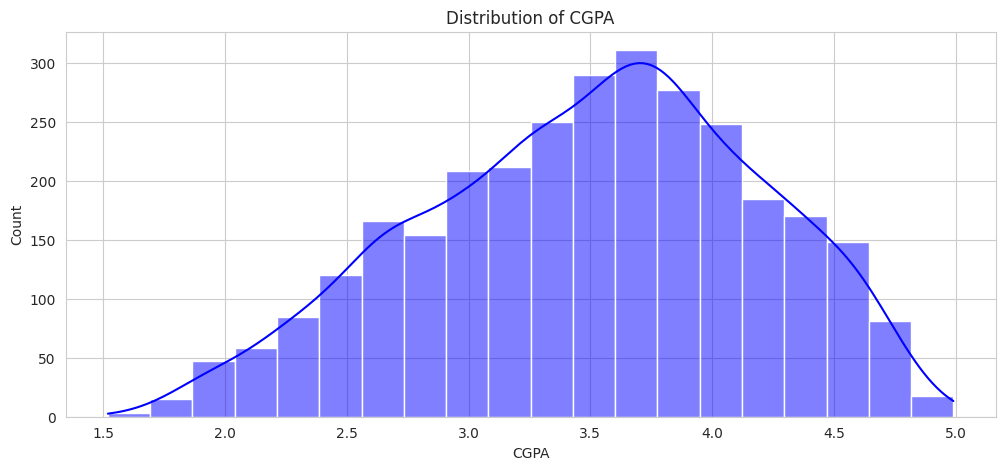

In [11]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))
sns.histplot(df["CGPA"], bins=20, kde=True, color="blue")
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()

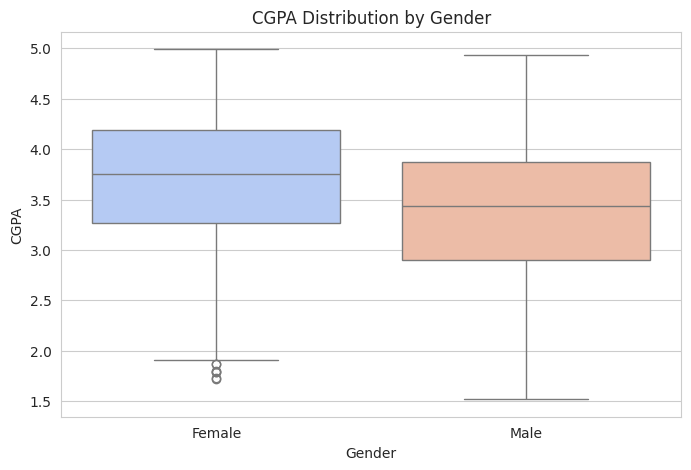

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Gender", y="CGPA", data=df, palette="coolwarm")
plt.title("CGPA Distribution by Gender")
plt.show()

In [14]:
def check_df(dataframe, head=5):
    print('##################### Shape #####################')
    print(dataframe.shape)
    print('##################### Types #####################')
    print(dataframe.dtypes)
    print('##################### Head #####################')
    print(dataframe.head(head))
    print('##################### Tail #####################')
    print(dataframe.tail(head))
    print('##################### NA #####################')
    print(dataframe.isnull().sum())
    print('##################### Quantiles #####################')
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

In [15]:
check_df(df)

##################### Shape #####################
(3046, 10)
##################### Types #####################
ID No          int64
Prog Code     object
Gender        object
YoG            int64
CGPA         float64
CGPA100      float64
CGPA200      float64
CGPA300      float64
CGPA400      float64
SGPA         float64
dtype: object
##################### Head #####################
   ID No Prog Code  Gender   YoG  CGPA  CGPA100  CGPA200  CGPA300  CGPA400  \
0  42308       ICE  Female  2010  3.23     2.88     3.48     2.62     2.90   
1  70978       BCH  Female  2010  3.58     3.25     4.26     3.37     3.47   
2  31602       BCH    Male  2010  2.21     1.78     1.98     1.49     2.51   
3  63847       BCH    Male  2010  2.70     2.67     2.44     2.00     2.35   
4  30158       BCH  Female  2010  3.88     3.61     3.69     3.63     4.58   

   SGPA  
0  3.13  
1  3.02  
2  2.19  
3  3.19  
4  4.24  
##################### Tail #####################
      ID No Prog Code  Gender   YoG  C

In [16]:
df = df.drop("CGPA300", axis=1)

In [17]:
df.head()

,ID No,Prog Code,Gender,YoG,CGPA,CGPA100,CGPA200,CGPA400,SGPA
0,42308,ICE,Female,2010,3.23,2.88,3.48,2.90,3.13
1,70978,BCH,Female,2010,3.58,3.25,4.26,3.47,3.02
2,31602,BCH,Male,2010,2.21,1.78,1.98,2.51,2.19
3,63847,BCH,Male,2010,2.70,2.67,2.44,2.35,3.19
4,30158,BCH,Female,2010,3.88,3.61,3.69,4.58,4.24


In [18]:
df["CGPA"].fillna(df["CGPA"].mean(), inplace=True)

In [19]:
df.head()

,ID No,Prog Code,Gender,YoG,CGPA,CGPA100,CGPA200,CGPA400,SGPA
0,42308,ICE,Female,2010,3.23,2.88,3.48,2.90,3.13
1,70978,BCH,Female,2010,3.58,3.25,4.26,3.47,3.02
2,31602,BCH,Male,2010,2.21,1.78,1.98,2.51,2.19
3,63847,BCH,Male,2010,2.70,2.67,2.44,2.35,3.19
4,30158,BCH,Female,2010,3.88,3.61,3.69,4.58,4.24


In [27]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == 'O']
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != 'O']
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == 'O']
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != 'O']
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f'Observations: {dataframe.shape[0]}')
    print(f'Variables: {dataframe.shape[1]}')
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car, num_but_cat

In [28]:
cat_cols, num_cols, cat_but_car, nums_but_car = grab_col_names(df)

Observations: 3046
Variables: 9
cat_cols: 3
num_cols: 6
cat_but_car: 0
num_but_cat: 1


In [29]:
cat_cols

['Prog Code', 'Gender', 'YoG']

In [30]:
num_cols

['ID No', 'CGPA', 'CGPA100', 'CGPA200', 'CGPA400', 'SGPA']

In [31]:
cat_but_car

[]

In [32]:
num_but_cat

NameError: name 'num_but_cat' is not defined

           Prog Code  Ratio
Prog Code                  
EEE              418  13.72
CIS              342  11.23
MIS              307  10.08
ICE              245   8.04
CEN              237   7.78
CHE              213   6.99
PET              207   6.80
MCE              184   6.04
CVE              167   5.48
MCB              164   5.38
BCH              148   4.86
CHM              111   3.64
BLD               97   3.18
PHYE              82   2.69
MAT               61   2.00
PHYG              37   1.21
PHYR              26   0.85
##########################################


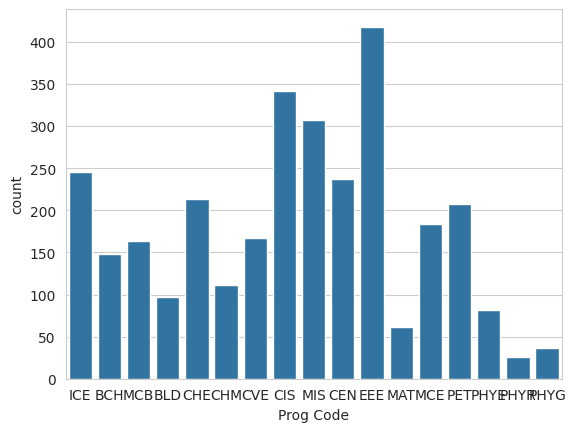

        Gender  Ratio
Gender               
Male      1953  64.12
Female    1093  35.88
##########################################


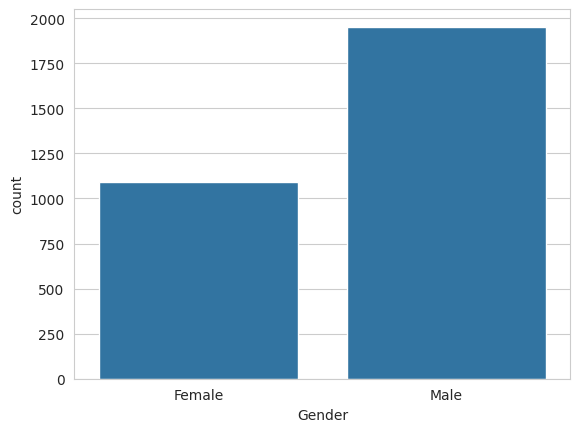

      YoG  Ratio
YoG             
2013  811  26.63
2012  714  23.44
2014  580  19.04
2011  471  15.46
2010  470  15.43
##########################################


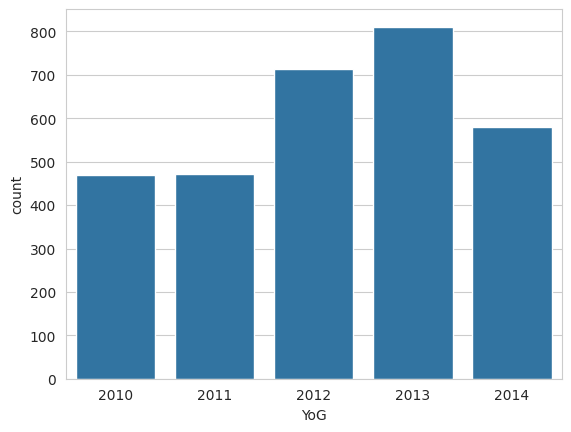

In [35]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        'Ratio': 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print('##########################################')
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

for col in cat_cols:
    cat_summary(df, col, plot=True)

In [36]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

    for col in num_cols:
        num_summary(df, col, plot=True)

           TARGET_MEAN
Prog Code             
BCH               3.54
BLD               3.33
CEN               3.52
CHE               3.67
CHM               3.56
CIS               3.47
CVE               3.46
EEE               3.64
ICE               3.50
MAT               3.38
MCB               3.48
MCE               3.53
MIS               3.24
PET               3.52
PHYE              3.42
PHYG              3.29
PHYR              3.47




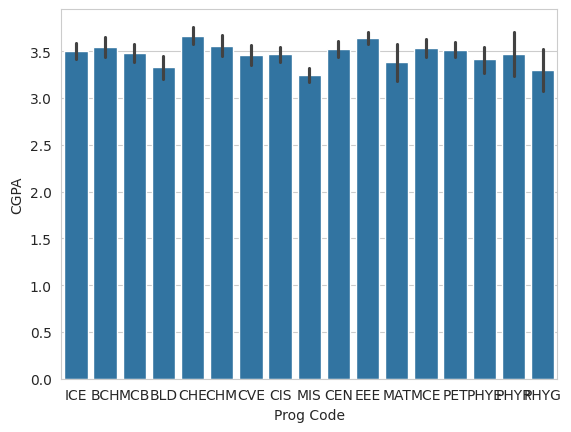

        TARGET_MEAN
Gender             
Female         3.68
Male           3.39




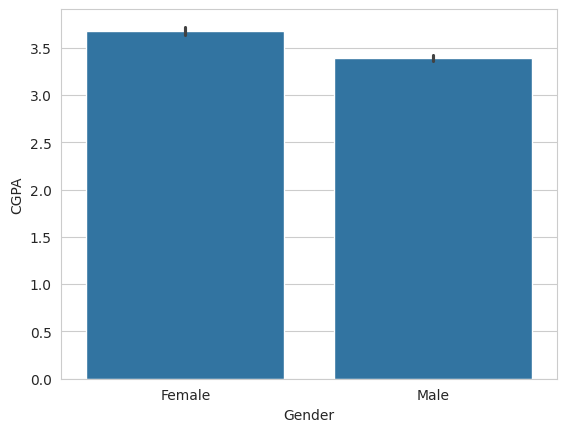

      TARGET_MEAN
YoG              
2010         3.54
2011         3.38
2012         3.49
2013         3.46
2014         3.61




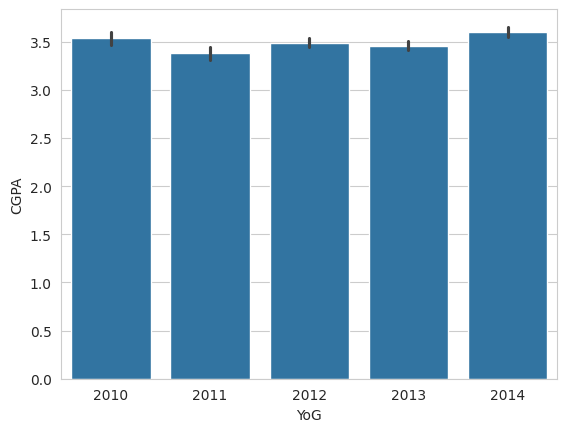

In [37]:
def target_summary_with_cat(dataframe, target, categorical_col, plot=False):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")
    if plot:
        sns.barplot(x=categorical_col, y=target, data=dataframe)
        plt.show(block=True)

for col in cat_cols:
    target_summary_with_cat(df, "CGPA", col, plot=True)

In [38]:
df.groupby("Gender").agg({"CGPA": "mean"})

,CGPA
Gender,
Female,3.68
Male,3.39


In [39]:
df.groupby("YoG").agg({"CGPA": "mean"})

,CGPA
YoG,
2010,3.54
2011,3.38
2012,3.49
2013,3.46
2014,3.61
